In [1]:
import os
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
import csv
import glob
import scipy
from scipy.optimize import curve_fit
import yastn
import yastn.tn.fpeps as peps

The Hamiltonian for 2D Ising model is
$$
-\sum_{<i,j>}X_i X_j - g \sum_i Z_i
$$
with $<i,j>$ indicating nearest-neighbor sites on a square lattice.  $Z_i$ and $X_i$ are Pauli matrices on $i$-th site.

The critical value of the field 
$$
g_c = 3.04438
$$

We start the evolution in the state fully polarized in the +$z$ direction, and consider evolution with $g = g_c/10$, $g_c$, and $2 g_c$


We scan various parameters controling PEPS evolution algorithm within Suzuki-Trotter scheme:

(g, environment used for truncation, PEPS symmetry, PEPS bond dimension, CTM dimension, dt)

In [2]:
gc = 3.04438
datas = {}
for fname in glob.glob("./data/**/res_*.npy", recursive=True):
    param = fname.split("/")
    g = float(param[-4][2:])
    which = param[-3][6:]
    sym = param[-2][4:]
    #
    nn = param[-1].split("_")
    D = eval(nn[1][2:])
    chi = int(nn[2][4:])
    dt = float(nn[3][3:-4])
    ind = (g, which, sym, D, chi, dt)

    datas[ind] = np.load(fname, allow_pickle=True).item()
    datas[ind]['fname'] = fname


In [3]:
def get_vals(val, g=None, which=None, sym=None, D=None, chi=None, dt=None, Eng_tol=None):
    dd = {}

    if D is not None and isinstance(D, int):
        D = [D]

    if Eng_tol is None:
        Eng_tol = 100

    for k, v in datas.items():
         if (g is None or abs(k[0] - g) < 1e-3) and \
           (which is None or k[1] == which) and \
           (sym is None or k[2] == sym) and \
           (D is None or k[3] in D) and \
           (chi is None or k[4] == chi) and \
           (dt is None or abs(k[5] - dt) < 1e-6):
            sfs = sorted([x for x in v if isinstance(x, float) and abs(v[x]['Eng'] + k[0]) < Eng_tol])
            dd[k] = (sfs, [v[sf][val] for sf in sfs])

    return dd

In [4]:
def plot_val(val, g=None, which=None, sym=None, D=None, chi=None, dt=None, Eng_tol=None):
    dd = get_vals(val, g, which, sym, D, chi, dt, Eng_tol)
    clrs = dict(zip(['BP', 'NN', 'NN+', 'NN+BP', 'Ladder+BP'], [plt.cm.tab10(i) for i in range(10)]))
    srts = dict(zip(['BP', 'NN', 'NN+', 'NN+BP', 'Ladder+BP'], [0, 1, 2, 3, 4]))
    fkey = lambda x: (x[0], srts[x[1]], x[2], x[3], x[4], x[5])
    mrks = dict(zip([4, 6, 8, 10, 12, 14, 16], '+x*o234'))

    kk = sorted(dd.keys(), key=fkey)
    mev =  int(np.ceil(max(len(x[0]) for x in dd.values()) / 20))
    tmax = max(x[0][-1] for x in dd.values())

    for k in kk:
        v = dd[k]
        color = clrs[k[1]]
        sb = '-' if k[2] == 'Z2' else '--'
        sb += mrks[k[3]]
        x, y = v
        plt.plot(x, y, sb, label=f"{k}", color=color, markevery=mev)

    if val == 'Eng':
        plt.plot([0, tmax], [-k[0], -k[0]], '--k')

    plt.xlabel("time")
    plt.ylabel(val)
    plt.xlim([0, tmax])
    plt.legend(loc=(1, 0))

In [13]:
def plotting_set(g = gc / 10, D = [4, 6, 8, 10], sym=None):
    plt.figure()
    plot_val('Eng', g=g, sym=sym, Eng_tol=0.1, D=D)
    plt.title(f"Energy {g=:0.3}")

    plt.figure()
    plot_val('Delta', g=g, sym=sym, Eng_tol=0.1, D=D)
    plt.title(f"Accumulated truncation error for {g=:0.3}");

    plt.figure()
    plot_val('eat_metric_error', g=g, sym=sym, D=D)
    plt.title(f"{g=:0.3}")
    plt.title(f"error of approximating truncation metric by a product {g=:0.3}");

    plt.figure()
    plot_val('Ez', g=g, sym=sym, D=D)
    plt.title(f"{g=:0.3}")
    plt.title(f"transverse magnetization {g=:0.3}");


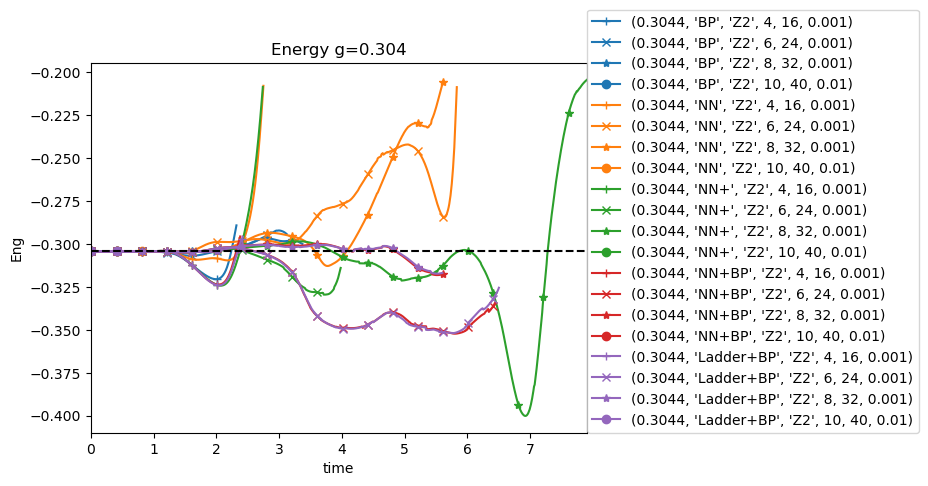

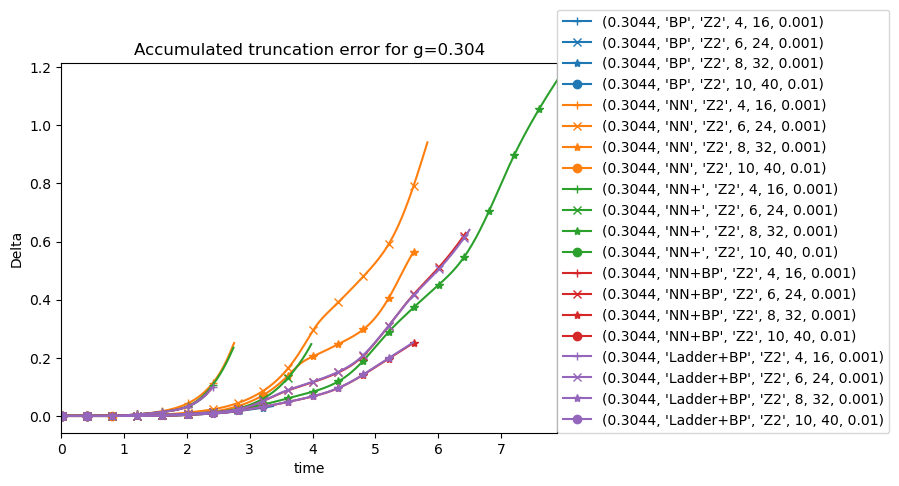

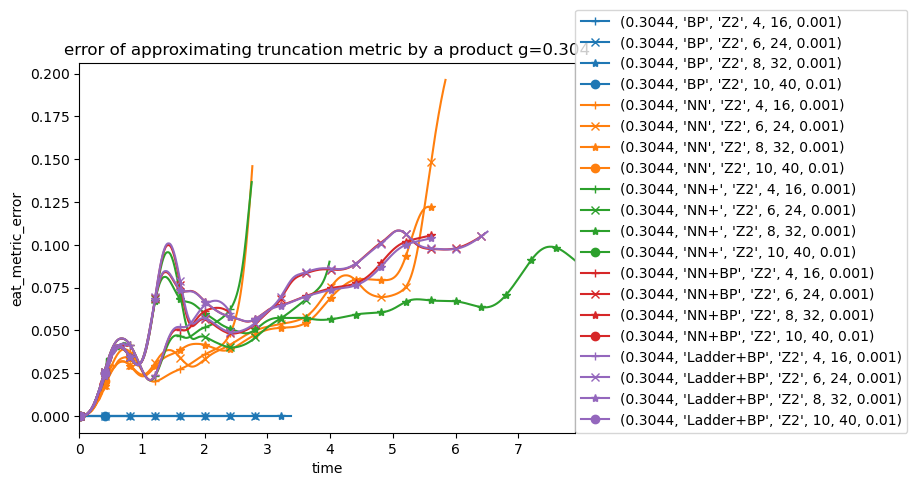

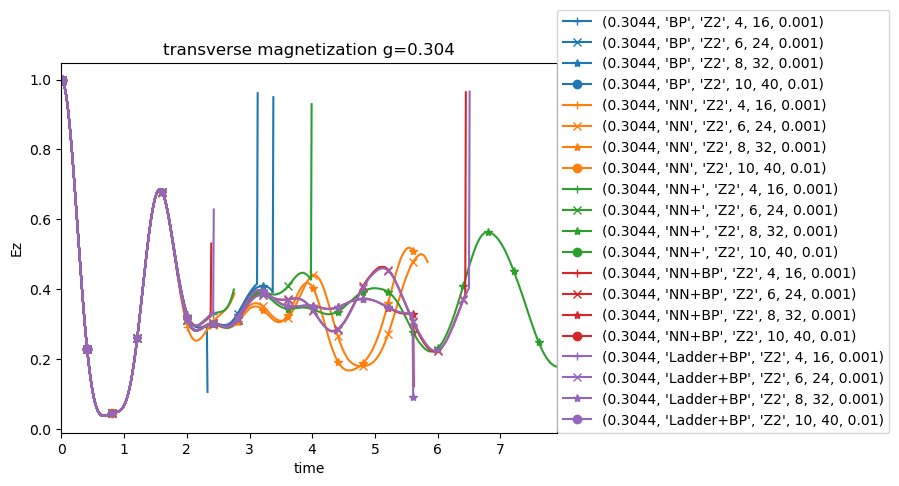

In [14]:
plotting_set(g=gc / 10, sym='Z2')

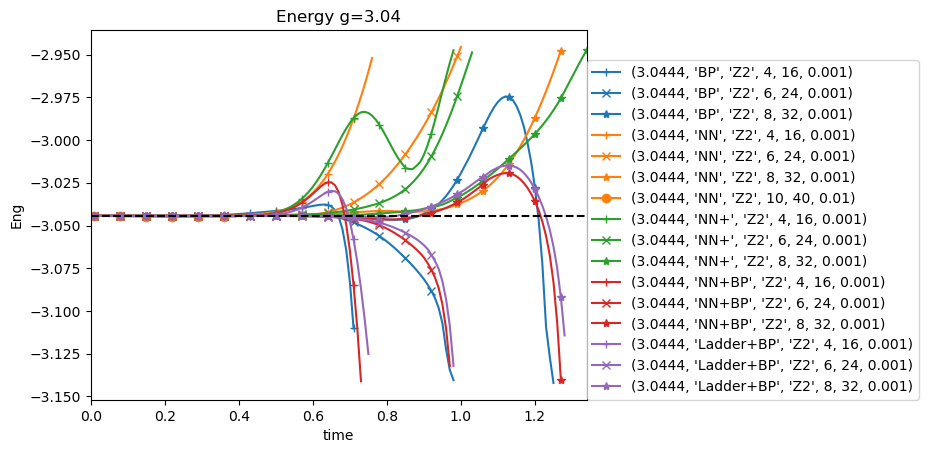

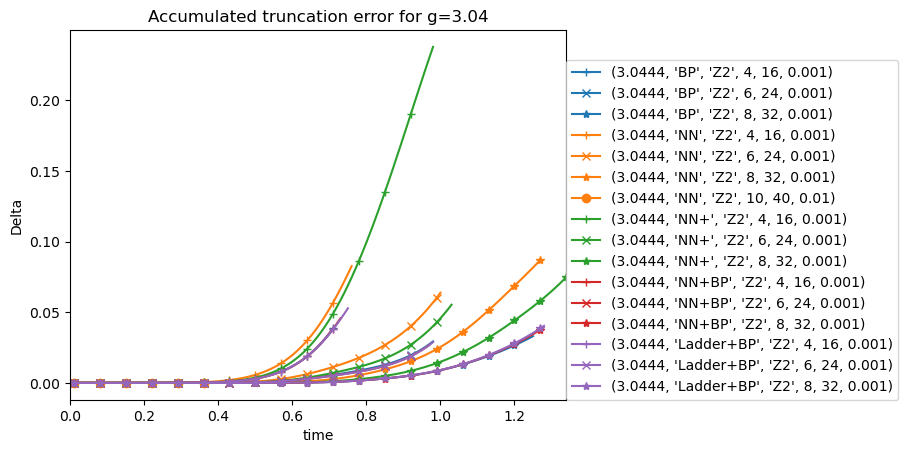

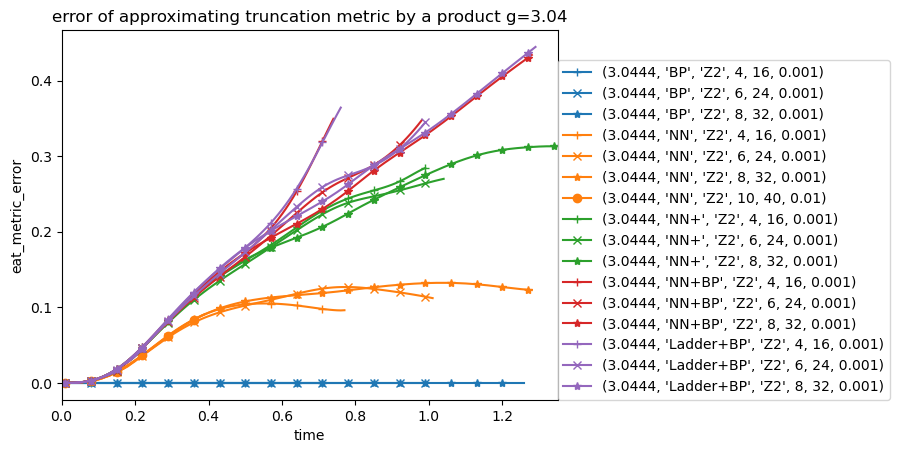

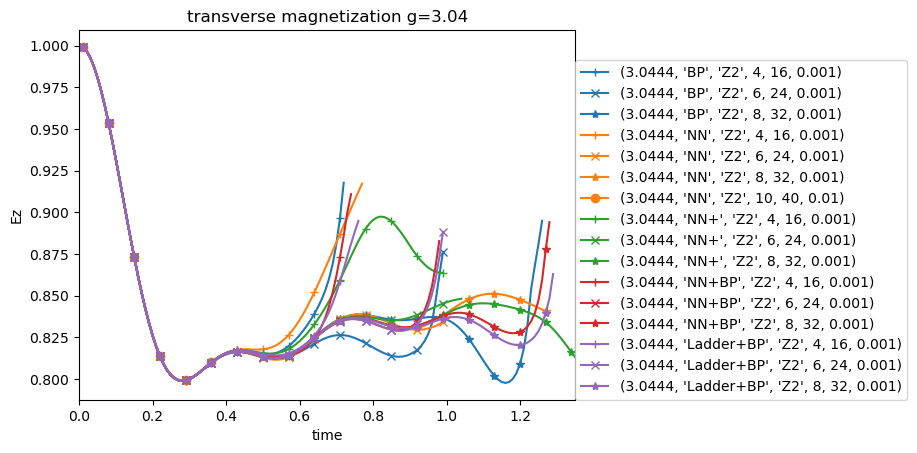

In [15]:
plotting_set(g=gc, sym='Z2')

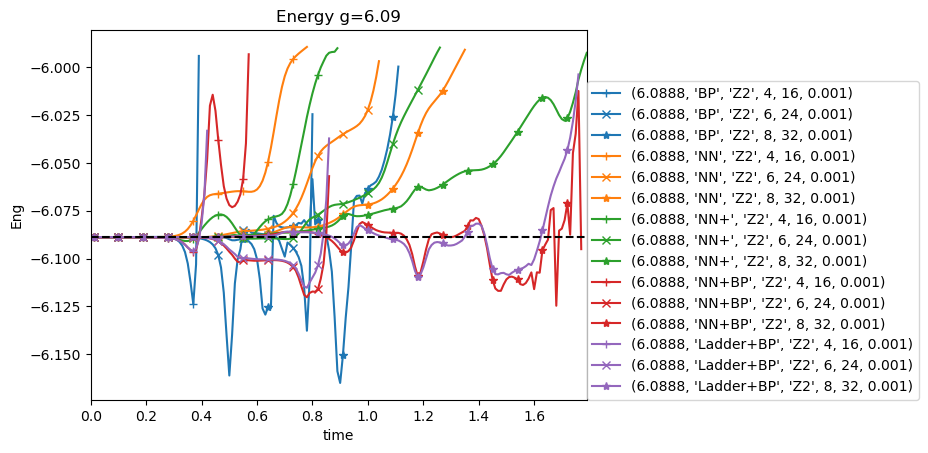

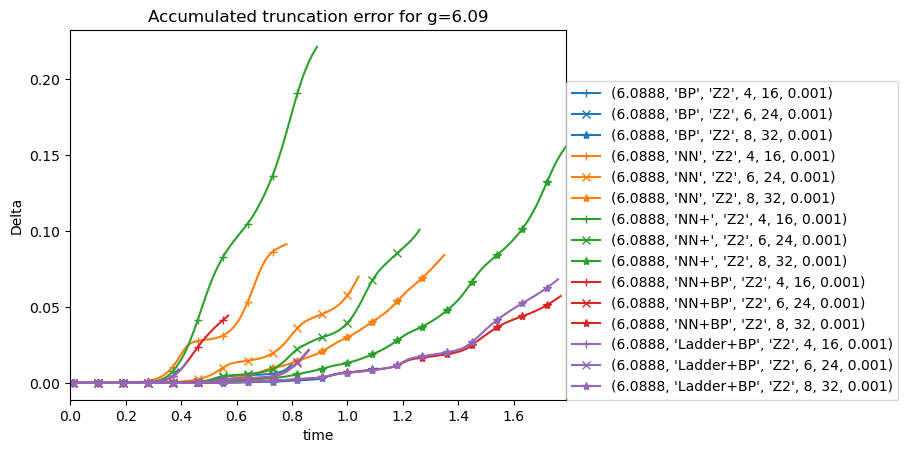

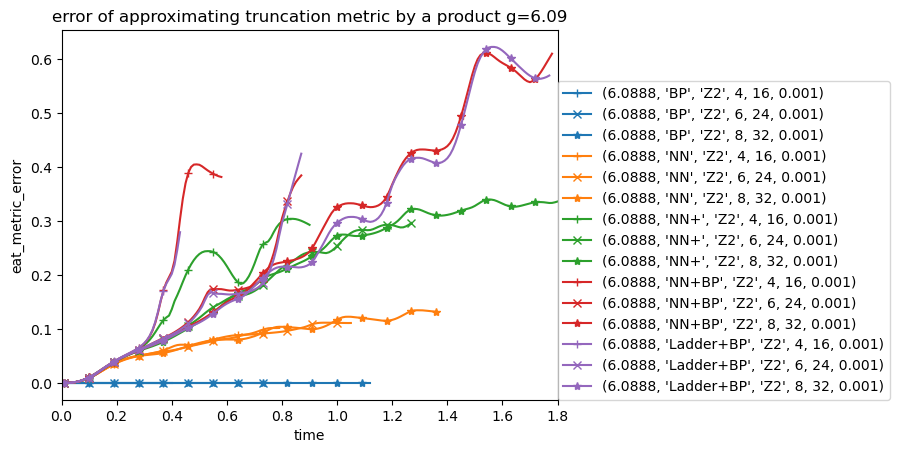

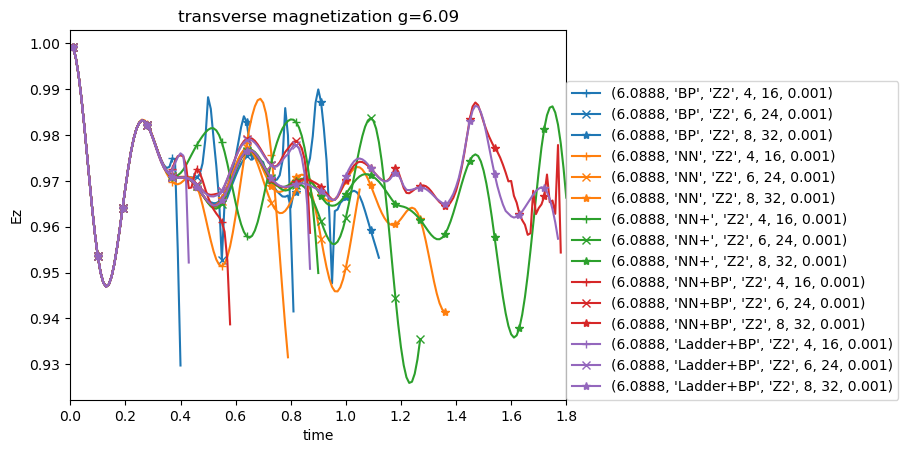

In [16]:
plotting_set(g=gc * 2, sym='Z2')

In [17]:
def plot_conv(g=None, which=None, sym=None, D=None, chi=None, dt=None, Eng_tol=None):
    dd = get_vals('Eng', g, which, sym, D, chi, dt, Eng_tol)

    conv_times = {}
    for k, (t, eng) in dd.items():
        i = np.argmax(abs(np.array(eng) + g) > 0.01)

        conv_times[k] = t[i - 1] if i > 0 else t[-1]

    clrs = dict(zip(['BP', 'NN', 'NN+', 'NN+BP', 'Ladder+BP'], [plt.cm.tab10(i) for i in range(10)]))
    srts = dict(zip(['BP', 'NN', 'NN+', 'NN+BP', 'Ladder+BP'], [0, 1, 2, 3, 4]))
    fkey = lambda x: (x[0], srts[x[1]], x[2], x[3], x[4], x[5])
    mrks = dict(zip([4, 6, 8, 10, 12, 14, 16], '+x*o234'))

    kk = sorted(dd.keys(), key=fkey)

    for k in kk:
        v = conv_times[k]
        color = clrs[k[1]]
        sb = mrks[k[3]]
        x, y = [k[3]], [v]
        plt.scatter(x, y, label=f"{k}", color=color, marker=sb)

    plt.xlabel("D")
    plt.ylabel('converged up to time')
    plt.legend(loc=(1, 0))


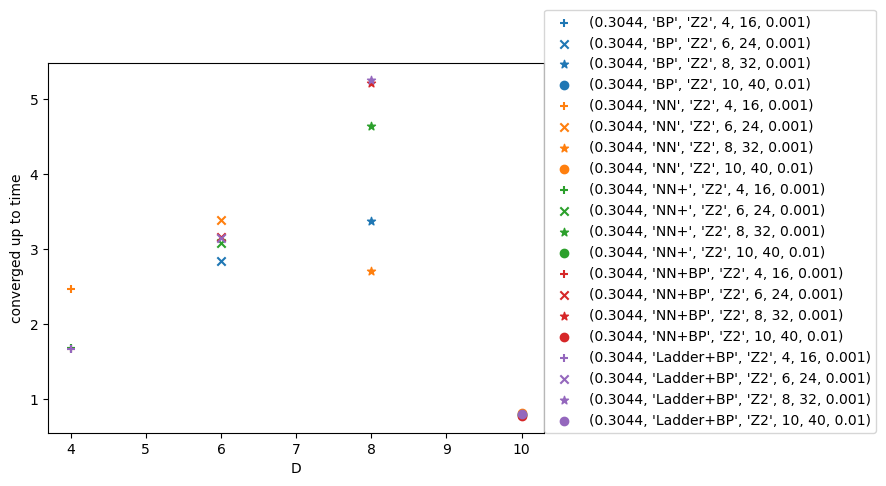

In [18]:
plot_conv(g=gc/10, sym='Z2')

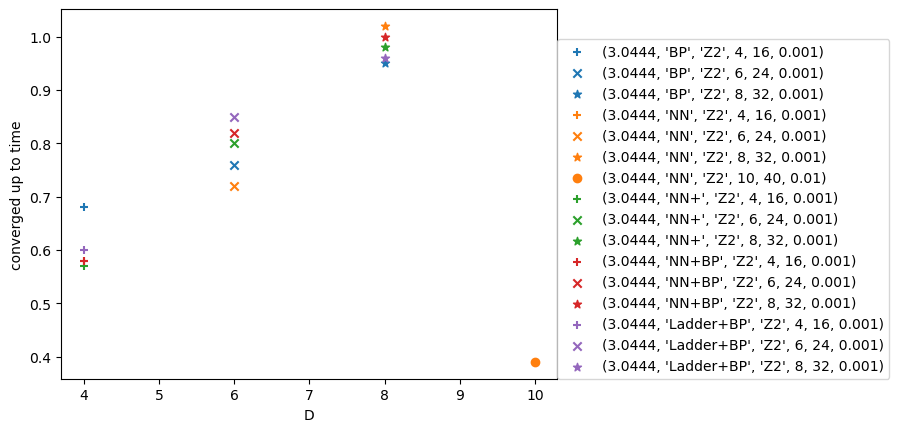

In [19]:
plot_conv(g=gc, sym='Z2')

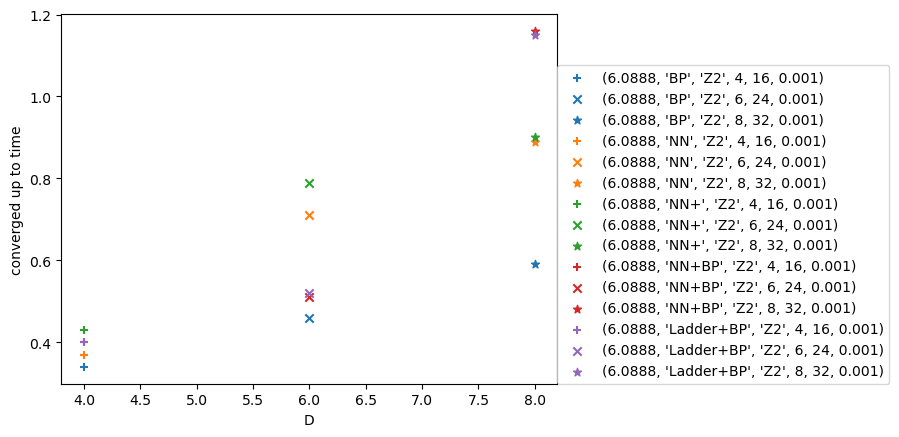

In [20]:
plot_conv(g=gc* 2, sym='Z2')